In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import dataset as ds
import models as m
import utils as u

device = 'cuda'

Training:   0%|          | 0/10 [00:00<?, ?it/s]

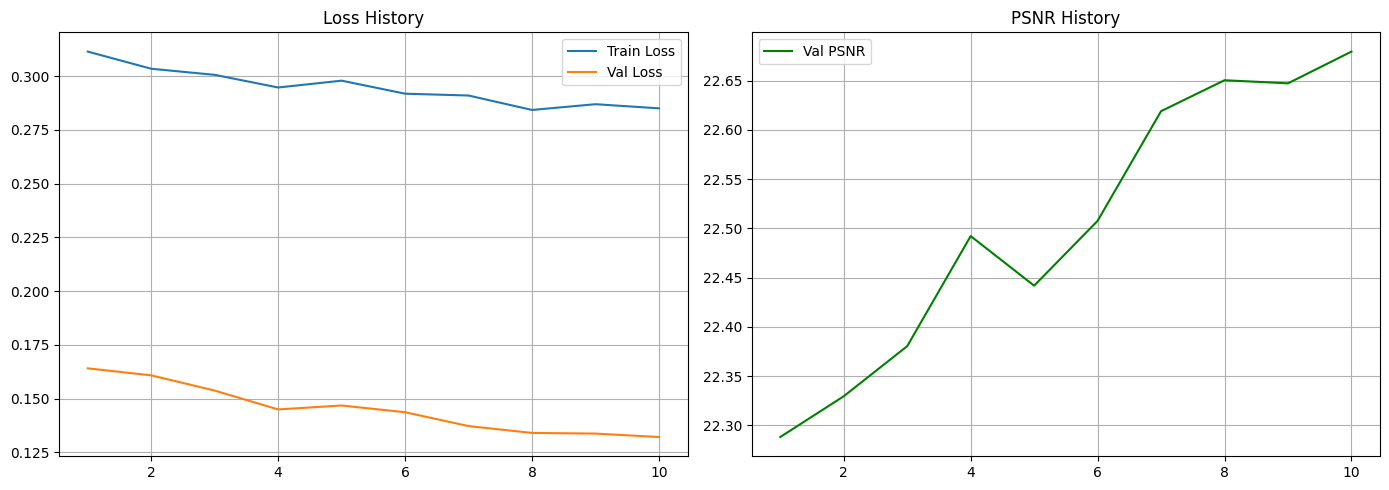

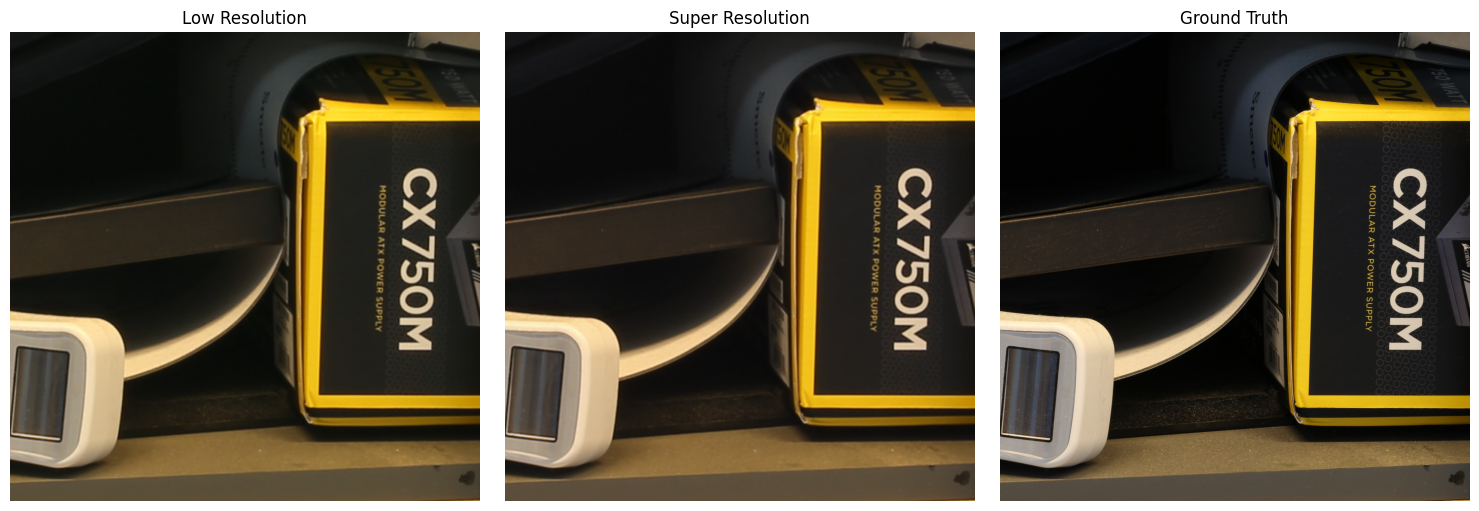

In [3]:
batch_sizes = {
    "train" : 16,
    "val" : 1,
    "test" : 1
}

train_ds, val_ds, test_ds = ds.get_SR_datasets(patch_size=128, lr=1, hr=4)
train_dl, val_dl, test_dl = ds.get_dataloaders(train_ds, val_ds, test_ds, batch_sizes)
model = m.ResidualSR(scale_factor=4).to(device)
criterion = u.SSIMLoss(alpha=0.8)
optimizer = optim.Adam(model.parameters(), lr=0.00001) 

u.training_loop(model, criterion, optimizer, 10, train_dl, val_dl, device)
u.visualize_results(model, val_dl, device, num_samples=1)

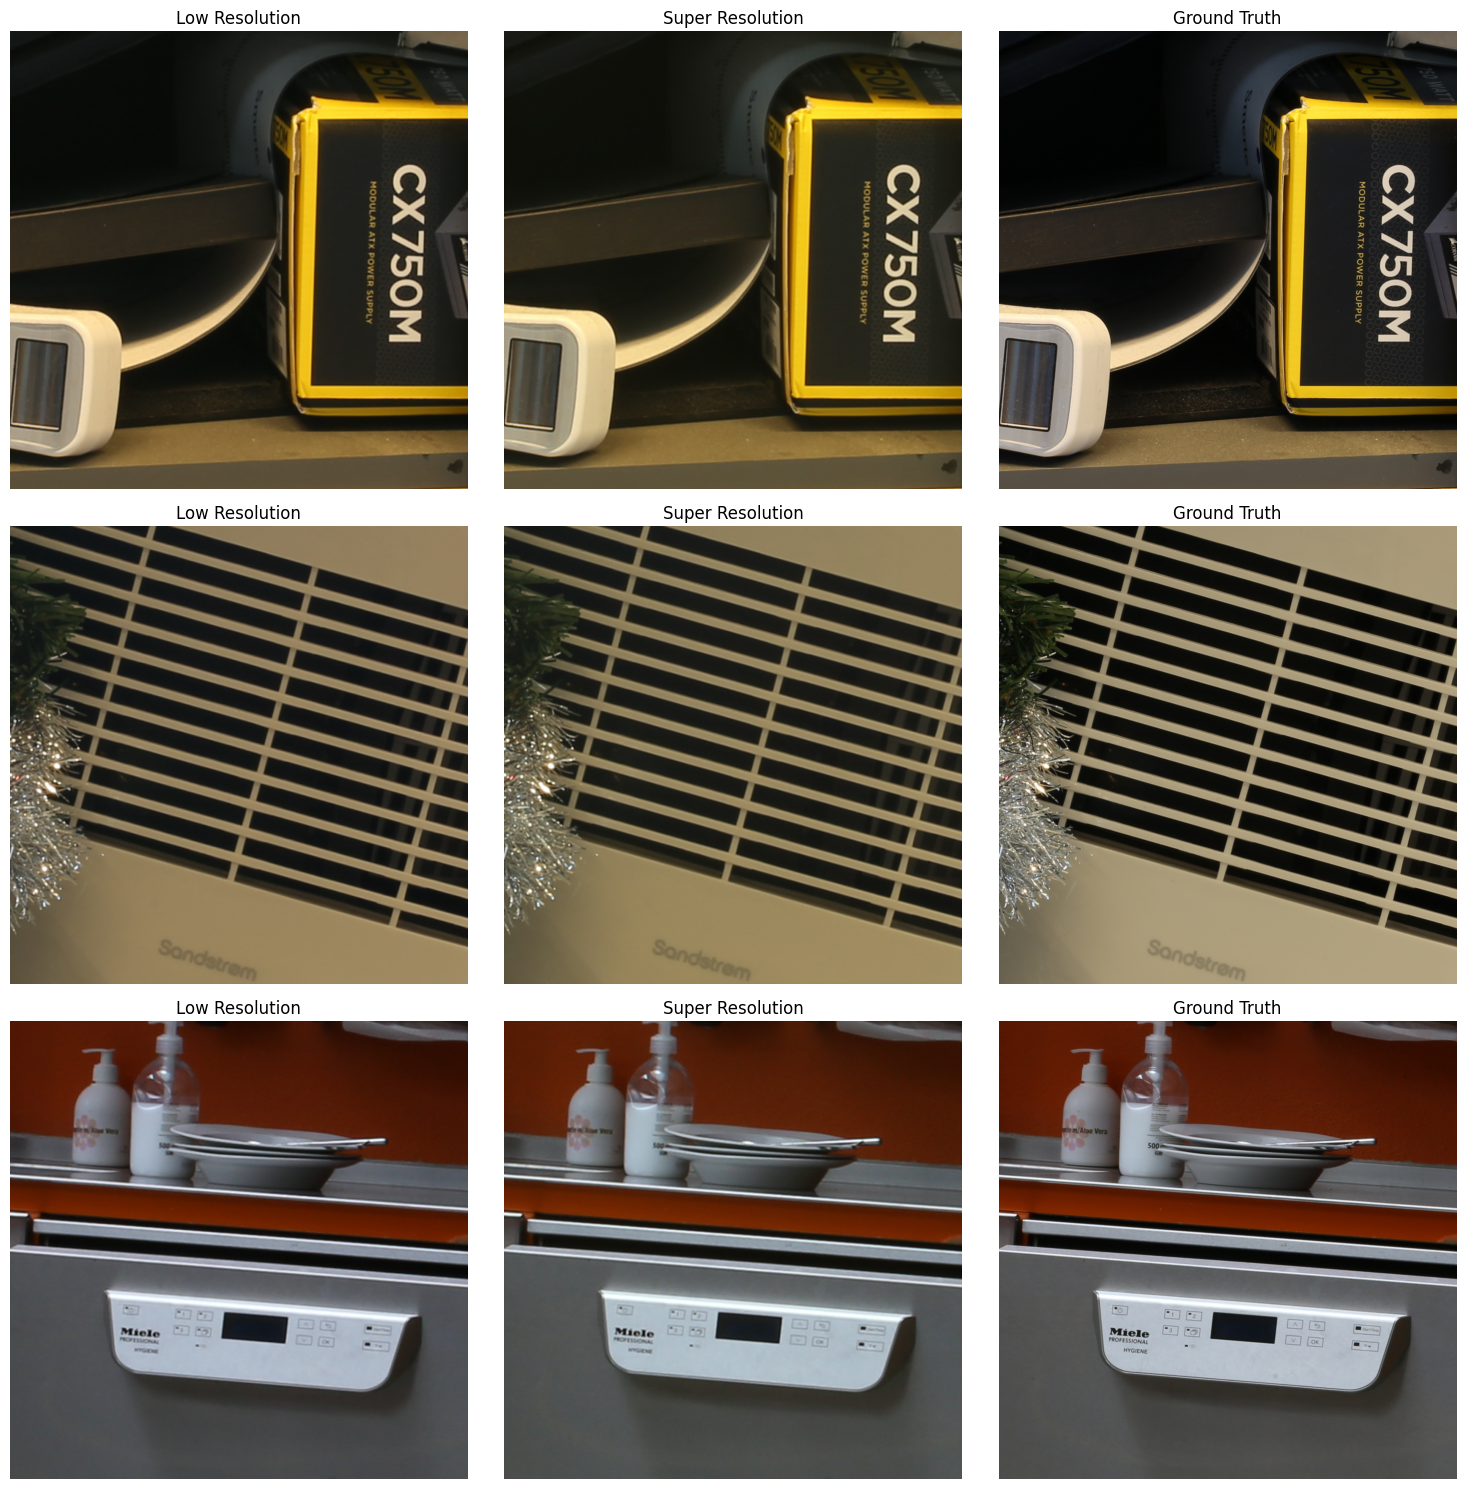

In [5]:
u.visualize_results(model, val_dl, device, num_samples=3)

Training:   0%|          | 0/25 [00:00<?, ?it/s]

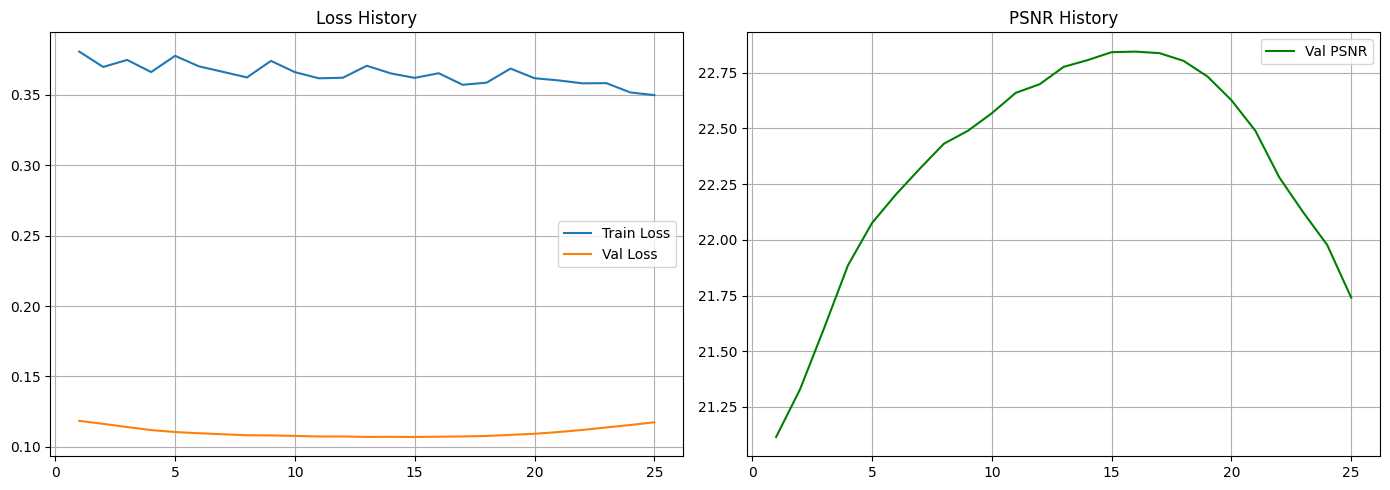

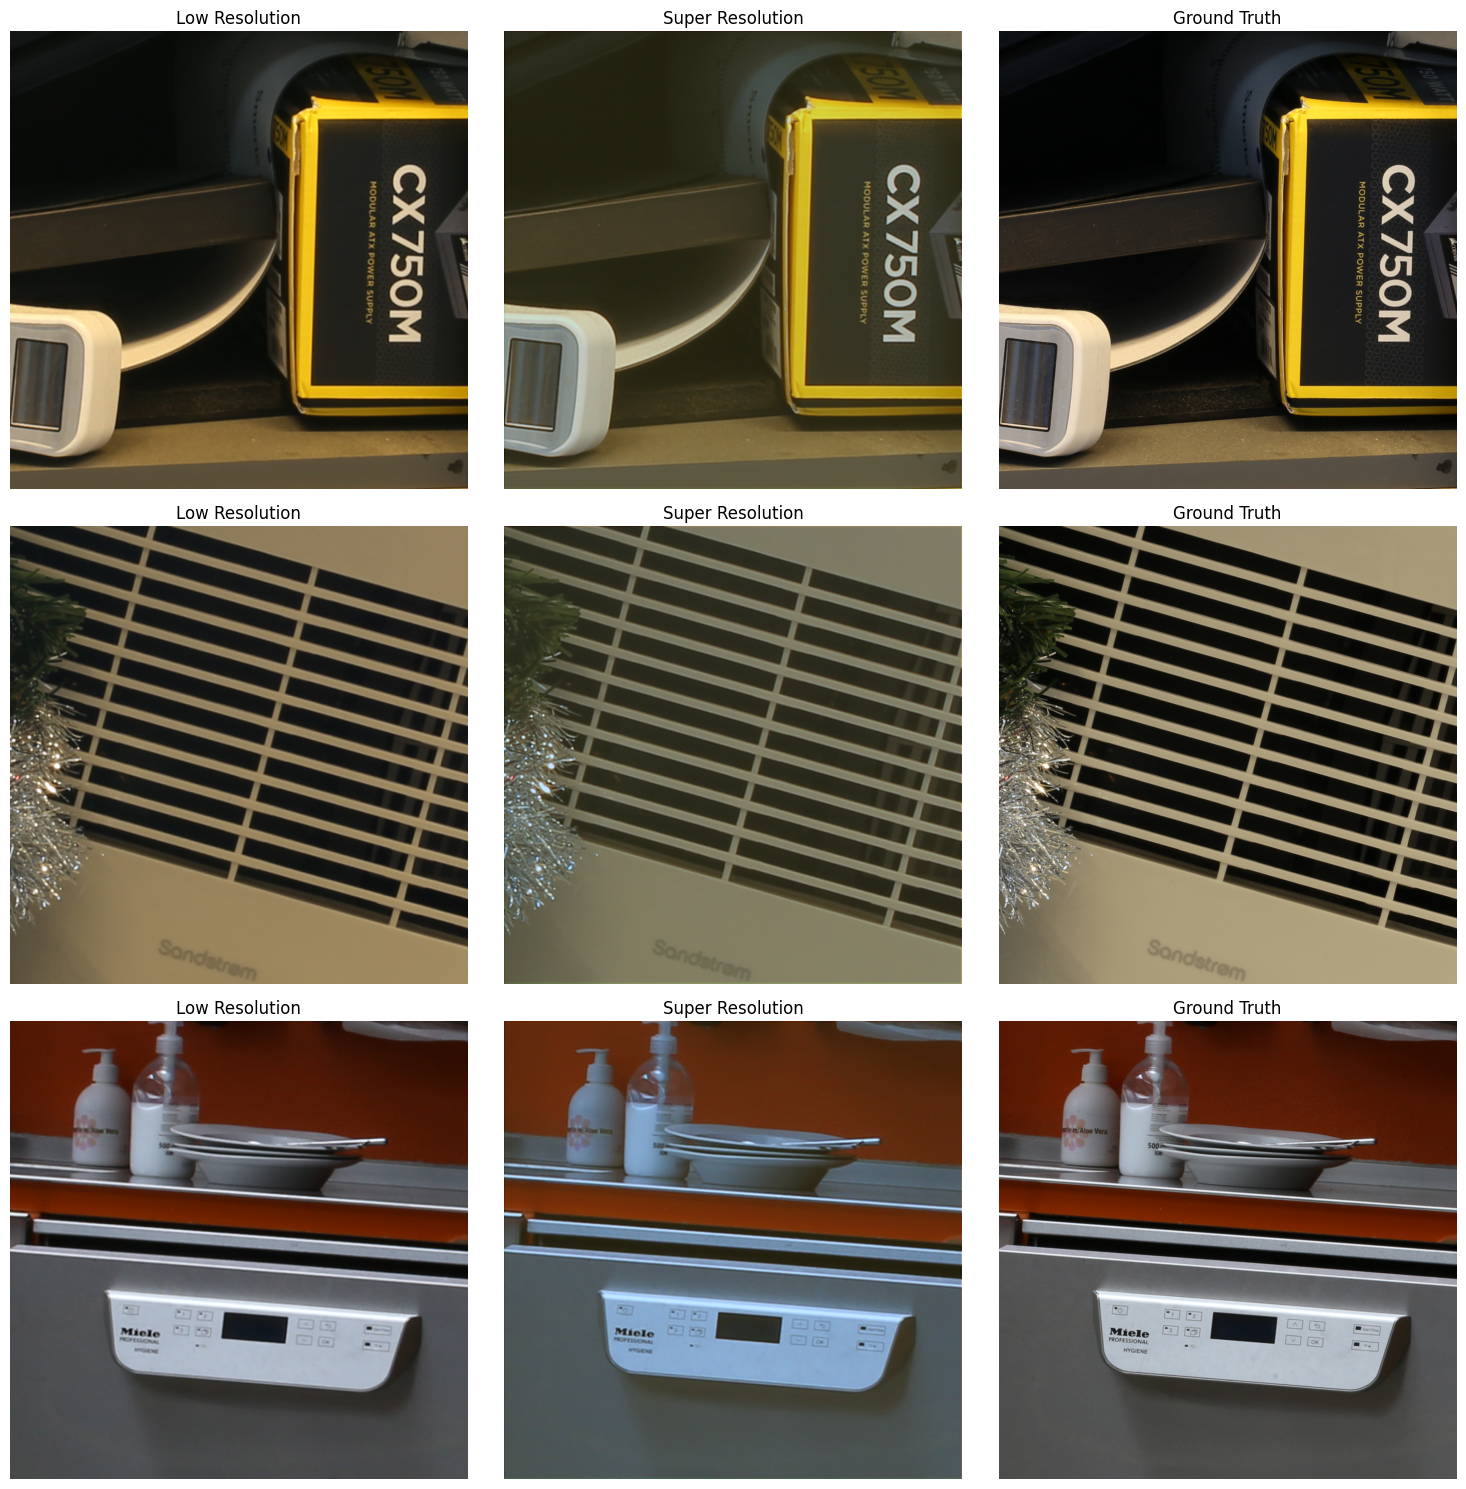

In [3]:
batch_sizes = {
    "train" : 32,
    "val" : 3,
    "test" : 3
}

train_ds, val_ds, test_ds = ds.get_SR_datasets(patch_size=64, lr=1, hr=2)
train_dl, val_dl, test_dl = ds.get_dataloaders(train_ds, val_ds, test_ds, batch_sizes)
model = m.SimpleSRPreUpscaled().to(device)
criterion = u.SSIMLoss(alpha=0.5)
optimizer = optim.Adam(model.parameters(), lr=0.00001) 

u.training_loop(model, criterion, optimizer, 25, train_dl, val_dl, device)
u.visualize_results(model, val_dl, device, num_samples=3)